In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Users\Kanti\Downloads\stocks.csv")

df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


(248, 8)

In [4]:
# Missing values
df.isnull().sum()

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [5]:
# Remove duplicates
df.duplicated().sum()

0

In [6]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove invalid rows
df = df.dropna(subset=['Date'])

# Sort by time
df = df.sort_values('Date')                                # Sort data

In [7]:
# Create new features
# Lag features (MOST IMPORTANT)
df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Lag_3'] = df['Close'].shift(3)

# Moving averages
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_50'] = df['Close'].rolling(50).mean()

# Returns
df['Return'] = df['Close'].pct_change()

# Volatility
df['Volatility'] = df['Close'].rolling(10).std()

In [8]:
df['Future_Close'] = df['Close'].shift(-1)

# Classification target
df['Target'] = (df['Future_Close'] > df['Close']).astype(int)

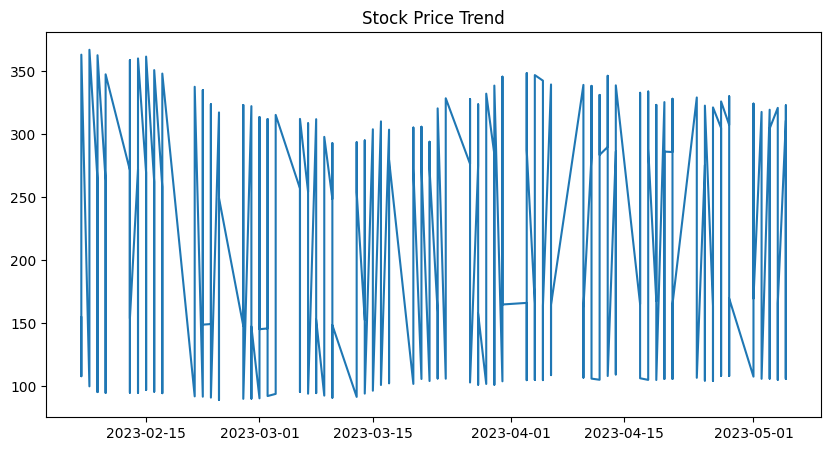

In [9]:
# Price trend
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.title("Stock Price Trend")
plt.show()

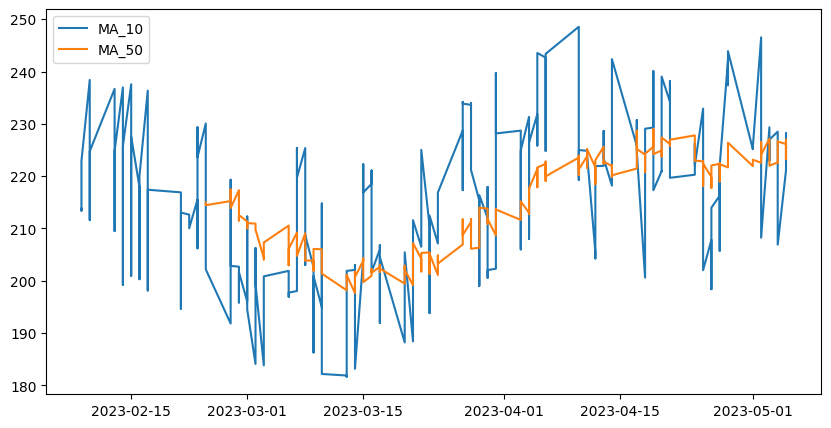

In [10]:
# Moving Average Trend
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['MA_10'], label='MA_10')
plt.plot(df['Date'], df['MA_50'], label='MA_50')
plt.legend()
plt.show()

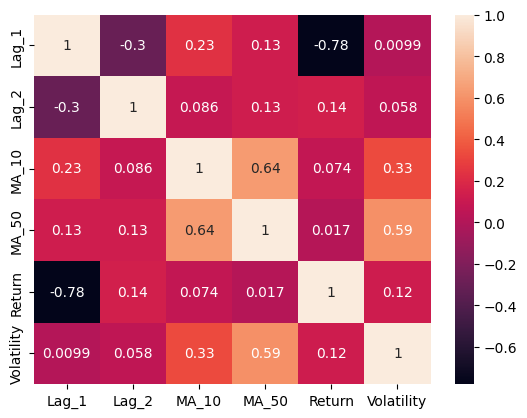

In [11]:
# Correlation Heatmap

sns.heatmap(df[['Lag_1','Lag_2','MA_10','MA_50','Return','Volatility']].corr(), annot=True)
plt.show()

In [12]:
# Target: Predict Close Price
features = ['Lag_1','Lag_2','Lag_3','MA_10','MA_50','Return','Volatility']

X = df[features]
y = df['Target']

In [13]:
# Train/Test Split
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [14]:
# Better Model: Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
# Prediction
y_pred = model.predict(X_test)

In [16]:
# Evaluation
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.76
              precision    recall  f1-score   support

           0       0.76      0.81      0.79        27
           1       0.76      0.70      0.73        23

    accuracy                           0.76        50
   macro avg       0.76      0.76      0.76        50
weighted avg       0.76      0.76      0.76        50



In [17]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

print(importance.sort_values(by="Importance", ascending=False))

      Feature  Importance
5      Return    0.437885
3       MA_10    0.148939
0       Lag_1    0.110806
2       Lag_3    0.094064
4       MA_50    0.081280
6  Volatility    0.065245
1       Lag_2    0.061780


In [18]:
# Predict Future Day
latest_data = X.tail(1)

prediction = model.predict(latest_data)
prob = model.predict_proba(latest_data)[0]

if prediction[0] == 1:
    print("📈 Market will go UP")
else:
    print("📉 Market will go DOWN")

print(f"UP Probability: {prob[1]*100:.2f}%")
print(f"DOWN Probability: {prob[0]*100:.2f}%")

📈 Market will go UP
UP Probability: 87.35%
DOWN Probability: 12.65%
